Second model submission (regularized / different algorithm)

Step #1 – Set up notebook and import libraries

In [1]:
# Basic setup
import pandas as pd
import numpy as np

# Visualization (optional but useful for assumptions)
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_log_error

Step #2 – Load datasets

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")


Step 3 — Encode categorical column (“Sex”)

In [3]:
cat_cols = ['Sex']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = encoder.fit_transform(train[cat_cols])
encoded_test = encoder.transform(test[cat_cols])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(cat_cols))
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(cat_cols))

train2 = train.drop(columns=cat_cols)
test2 = test.drop(columns=cat_cols)

train2 = pd.concat([train2, encoded_train_df], axis=1)
test2 = pd.concat([test2, encoded_test_df], axis=1)


Step 4 — Define features and target

In [4]:
target_col = "Rings"
feature_cols = [c for c in train2.columns if c != target_col]

X = train2[feature_cols]
y = train2[target_col]
X_test = test2[feature_cols]


Step 5 — Train/validation split

In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Step 6 — Build Lasso pipeline

In [6]:
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001, max_iter=10000, random_state=42))
])

lasso_pipe.fit(X_train, y_train)
y_valid_pred_lasso = lasso_pipe.predict(X_valid)

#FIX — Clip negative predictions so RMSLE does not error
y_valid_pred_lasso = np.maximum(y_valid_pred_lasso, 0)

#Compute RMSLE safely
rmsle_lasso = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred_lasso))
print("Lasso RMSLE (validation):", rmsle_lasso)



Lasso RMSLE (validation): 0.16674265027913246


Step 7 — Coefficient inspection

In [7]:
coef = lasso_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": coef
}).sort_values("coef", ascending=False)

coef_df


,feature,coef
7,Shell weight,2.754566
4,Whole weight,1.597809
3,Height,0.757178
2,Diameter,0.683170
8,Sex_F,0.009855
10,Sex_M,0.000000
0,id,-0.015241
1,Length,-0.117937
9,Sex_I,-0.332677
6,Whole weight.2,-0.650127


Step 8 — Residual diagnostics

C:\Users\sjrey\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


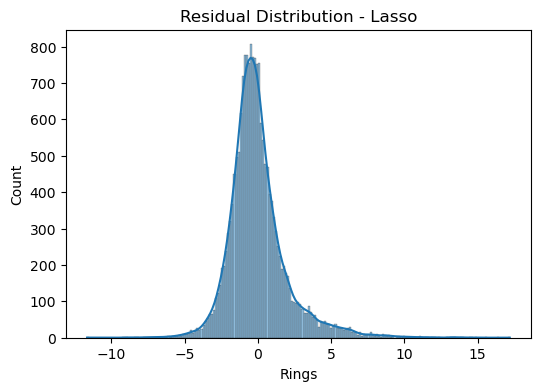

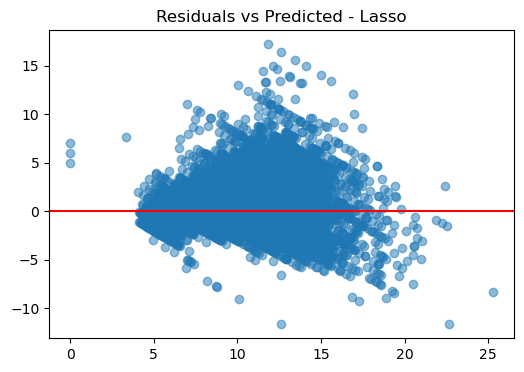

In [8]:
residuals_lasso = y_valid - y_valid_pred_lasso

plt.figure(figsize=(6,4))
sns.histplot(residuals_lasso, kde=True)
plt.title("Residual Distribution - Lasso")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_valid_pred_lasso, residuals_lasso, alpha=0.5)
plt.axhline(0, color="red")
plt.title("Residuals vs Predicted - Lasso")
plt.show()


Step 9 — Train on full dataset

In [9]:
lasso_pipe_full = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001, max_iter=10000, random_state=42))
])

lasso_pipe_full.fit(X, y)
test_pred_lasso = lasso_pipe_full.predict(X_test)


Step 10 — Create SECOND Kaggle submission

In [10]:
submission_lasso = sample_submission.copy()
submission_col = submission_lasso.columns[-1]

submission_lasso[submission_col] = test_pred_lasso
submission_lasso.to_csv("submission_model2_lasso.csv", index=False)

print("Second submission saved: submission_model2_lasso.csv")


Second submission saved: submission_model2_lasso.csv
